# **Limpieza de datos**

##**1.1: Limpieza y auditoría**

###Importacion de librerias

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Importacion de datos scrapeados

In [171]:
#Importacion datos de calles
url='https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos%20Contextuales/callejero.csv'
df_calles=pd.read_csv(url)

In [172]:
#Importacion archivos ventas
url='https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/datos_argenprop_ventas.tsv'
df_vtas_argen=pd.read_csv(url,sep='\t')
url='https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/datos_mercadolibre_ventas.csv'
df_vtas_ml=pd.read_csv(url)
url='https://raw.githubusercontent.com/kiaranatale/Trabajo-Practico-Real-State-Analytics/refs/heads/main/Datos2/datos_remax_venta.csv'
df_vtas_remax=pd.read_csv(url)

###Vista de datos

###Vista df_calles:

In [173]:
df_calles.head()

,id,codigo,nomoficial,nom_mapa,nomanter,tipo_c,long,sentido,bicisenda,red_jerarq,...,alt_izqfin,alt_derini,alt_derfin,comuna,com_par,com_impar,barrio,barrio_par,barrio_imp,observa
0,1,3054,"CANTILO, INT.",INT. CANTILO,NaN,CALLE,436.858613,CRECIENTE,NaN,VÍA TRONCAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,NaN
1,2,12152,"LUGONES, LEOPOLDO AV.",AV. LEOPOLDO LUGONES,NaN,AVENIDA,295.580867,CRECIENTE,NaN,VÍA TRONCAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,corrección nombre 9-1-03
2,3,17041,"PAZ, GRAL. AV.",AV.GRAL PAZ,ZUFRIATEGUI(PARCIAL),AVENIDA,145.474786,DECRECIENTE,NaN,VÍA TRONCAL,...,300,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,NaN
3,4,12107,DEL LIBERTADOR AV.,AV.DEL LIBERTADOR,"DEL LIBERTADOR GENERAL SAN MARTIN, Av.(parcial...",AVENIDA,10.152599,DOBLE,NaN,VÍA DISTRIBUIDORA PRINCIPAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,NaN
4,5,3054,"COLECTORA CANTILO, INT.",Colectora INT. CANTILO,"CANTILO, Int.",CALLE,78.551117,CRECIENTE,NaN,VÍA LOCAL,...,0,0,0,13.0,13.0,13.0,NUÑEZ,NUÑEZ,NUÑEZ,Agregado en el nombre de Colectora por ser par...


In [174]:
df_calles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31956 entries, 0 to 31955
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          31956 non-null  int64  
 1   codigo      31956 non-null  int64  
 2   nomoficial  31956 non-null  object 
 3   nom_mapa    31910 non-null  object 
 4   nomanter    12480 non-null  object 
 5   tipo_c      31955 non-null  object 
 6   long        31956 non-null  float64
 7   sentido     31955 non-null  object 
 8   bicisenda   7 non-null      object 
 9   red_jerarq  31955 non-null  object 
 10  tipo_ffcc   31955 non-null  object 
 11  alt_izqini  31956 non-null  int64  
 12  alt_izqfin  31956 non-null  int64  
 13  alt_derini  31956 non-null  int64  
 14  alt_derfin  31956 non-null  int64  
 15  comuna      31956 non-null  object 
 16  com_par     31956 non-null  object 
 17  com_impar   31956 non-null  object 
 18  barrio      30227 non-null  object 
 19  barrio_par  31868 non-nul

In [175]:
df_calles.describe()

,id,codigo,long,alt_izqini,alt_izqfin,alt_derini,alt_derfin
count,31956.000000,31956.000000,31956.000000,31956.000000,31956.000000,31956.000000,31956.000000
mean,16447.716986,15771.227438,108.270889,2289.722493,2360.976092,2254.417856,2325.698836
std,9518.005861,21609.058206,87.528423,2026.232890,2039.180426,1963.506692,1978.170850
min,1.000000,1000.000000,2.727185,0.000000,0.000000,0.000000,0.000000
25%,8256.750000,3202.000000,67.323874,552.000000,600.000000,501.000000,599.000000
50%,16375.500000,12067.000000,103.985444,1902.000000,2000.000000,1901.000000,1999.000000
75%,24550.250000,19053.000000,131.352256,3602.000000,3660.000000,3531.000000,3599.000000
max,33120.000000,200000.000000,3113.053642,17692.000000,17700.000000,17401.000000,17699.000000


In [176]:
df_calles.shape

(31956, 22)

###Vista df_vtas_argen

In [177]:
df_vtas_argen.head()

,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,Dormitorios,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
0,USD 2.500.000,ARS 2.400.000,Jerónimo Salguero,2700.0,NaN,280 m² cubie. 3 dorm. 17 años,“TORRE BELLINI” DE REVISTA! IMPECABLE PISO MUY...,https://www.argenprop.com/departamento-en-vent...,5.0,3.0,...,1,0,1,1,0,1,1,0,1,0
1,USD 150.000,ARS 260.000,Bulnes,1600.0,NaN,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3.0,2.0,...,0,0,0,1,1,1,0,0,1,0
2,USD 113.000,ARS 116.000,Ángel Justianiano Carranza,2300.0,NaN,40 m² cubie. 30 años 1 baño,IMPECABLE MONOAMBIENTE! ESPECTACULAR VISTA ABI...,https://www.argenprop.com/departamento-en-vent...,1.0,NaN,...,0,0,1,0,0,1,0,0,1,0
3,USD 330.000,ARS 203.300,ARAOZ,1200.0,8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4.0,3.0,...,0,0,0,0,0,0,1,0,1,0
4,USD 270.000,ARS 300.000,Honduras,3900.0,2º,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4.0,2.0,...,0,0,0,0,0,1,1,0,1,1


In [178]:
df_vtas_argen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1979 entries, 0 to 1978
Data columns (total 65 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precio                                       1979 non-null   object 
 1   Expensas                                     1466 non-null   object 
 2   Calle                                        1979 non-null   object 
 3   Altura                                       1737 non-null   float64
 4   Piso                                         820 non-null    object 
 5   Detalles                                     1977 non-null   object 
 6   Descripción                                  1979 non-null   object 
 7   Link                                         1979 non-null   object 
 8   Ambientes                                    1959 non-null   float64
 9   Dormitorios                                  1670 non-null   float64
 10  

In [179]:
df_vtas_argen.describe()

,Altura,Ambientes,Dormitorios,Baños,Toilettes,Antiguedad,Expensas_Ficha,Cant_Pisos_Edificio,Deptos_Por_Piso,Antiguedad_Edificio,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
count,1737.000000,1959.000000,1670.000000,1920.000000,132.000000,1483.000000,0.0,651.000000,578.000000,0.0,...,1979.000000,1979.0,1979.000000,1979.000000,1979.000000,1979.000000,1979.000000,1979.000000,1979.000000,1979.000000
mean,2299.288428,2.675345,1.969461,1.477604,1.053030,35.043830,NaN,9.087558,4.164360,NaN,...,0.026276,0.0,0.021728,0.044467,0.161698,0.083375,0.430015,0.109146,0.715513,0.120263
std,1718.323816,1.151789,0.916346,0.728715,0.310488,20.924002,NaN,4.943062,4.098735,NaN,...,0.159995,0.0,0.145831,0.206182,0.368266,0.276519,0.495203,0.311901,0.451284,0.325351
min,0.000000,0.000000,1.000000,1.000000,1.000000,-2.000000,NaN,1.000000,1.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,2.000000,1.000000,1.000000,1.000000,15.000000,NaN,6.500000,2.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2100.000000,3.000000,2.000000,1.000000,1.000000,40.000000,NaN,9.000000,4.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3300.000000,3.000000,3.000000,2.000000,1.000000,50.000000,NaN,11.000000,4.000000,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,12400.000000,8.000000,7.000000,5.000000,4.000000,113.000000,NaN,44.000000,39.000000,NaN,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [180]:
df_vtas_argen.shape

(1979, 65)

###Vistas df_vtas_ml

In [181]:
df_vtas_ml.head()

,Precio,Expensas,Calle,Altura,Piso,Link,Ambientes,Dormitorios,Baños,Toilettes,...,Vigilancia,Acceso_mov_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado,Precio_m2,Barrio
0,49000,92857,Sarmiento,1169,PB,https://departamento.mercadolibre.com.ar/MLA-1...,2,1,1,0,...,0,0,0,0,0,0,0,0,1633.33,San Nicolás
1,62000,120000,Beruti,2877,3.0,https://departamento.mercadolibre.com.ar/MLA-3...,2,1,1,0,...,0,0,0,0,0,0,0,0,2480.00,Recoleta
2,50000,0,Yerbal,600,PB,https://departamento.mercadolibre.com.ar/MLA-1...,0,0,0,0,...,0,0,0,0,0,0,0,0,0.00,Caballito
3,100000,245000,Charcas,2900,PB,https://departamento.mercadolibre.com.ar/MLA-1...,3,2,1,0,...,0,0,0,0,0,0,0,0,2272.73,Recoleta
4,58900,0,Av La Plata,300,PB,https://departamento.mercadolibre.com.ar/MLA-3...,0,0,0,0,...,0,0,0,0,0,0,0,0,0.00,Caballito


In [182]:
df_vtas_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Precio                         336 non-null    int64  
 1   Expensas                       336 non-null    int64  
 2   Calle                          336 non-null    object 
 3   Altura                         336 non-null    object 
 4   Piso                           336 non-null    object 
 5   Link                           336 non-null    object 
 6   Ambientes                      336 non-null    int64  
 7   Dormitorios                    336 non-null    int64  
 8   Baños                          336 non-null    int64  
 9   Toilettes                      336 non-null    int64  
 10  Estado                         336 non-null    object 
 11  Antiguedad                     336 non-null    int64  
 12  Disposicion                    336 non-null    obj

In [183]:
df_vtas_ml.describe()

,Precio,Expensas,Ambientes,Dormitorios,Baños,Toilettes,Antiguedad,Tipo_Balcon,Apto_Profesional,Apto_Credito,...,Seguridad_24hs,Vigilancia,Acceso_mov_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado,Precio_m2
count,3.360000e+02,3.360000e+02,336.000000,336.000000,336.000000,336.0,336.000000,336.0,336.0,336.0,...,336.0,336.0,336.0,336.0,336.0,336.0,336.0,336.0,336.0,336.000000
mean,2.254755e+05,1.057890e+05,1.342262,0.830357,0.651786,0.0,16.020833,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1121.688631
std,3.723323e+05,1.969431e+05,1.965098,1.186152,0.871196,0.0,23.307859,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1306.926698
min,2.500000e+04,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,8.950000e+04,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,1.370000e+05,0.000000e+00,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
75%,2.150000e+05,1.510000e+05,3.000000,2.000000,1.000000,0.0,35.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2191.562500
max,4.000000e+06,1.600000e+06,21.000000,5.000000,5.000000,0.0,95.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4835.590000


In [184]:
df_vtas_ml.shape

(336, 65)

###Vista df_vtas_remax

In [185]:
df_vtas_remax.head()

,Precio,Expensas,Calle,Altura,Piso,Link,Ambientes,Dormitorios,Baños,Toilettes,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
0,112.000 USD,NaN,SAN PEDRO,7100.0,NaN,https://www.remax.com.ar/listings/venta-casa-c...,5.0,4.0,1.0,NaN,...,0,0,0,0,0,0,1,0,1,0
1,197.000 USD,NaN,BARADERO,200.0,NaN,https://www.remax.com.ar/listings/venta-casa-a...,7.0,6.0,3.0,1.0,...,0,0,0,0,0,0,1,0,1,0
2,105.000 USD,NaN,PASAJE ESQUINA,2400.0,NaN,https://www.remax.com.ar/listings/venta-ph-3-a...,3.0,2.0,1.0,NaN,...,0,0,0,0,0,0,1,0,1,0
3,410.000 USD,600.000 ARS,SANTA FE AV.,1200.0,NaN,https://www.remax.com.ar/listings/semipiso-rec...,4.0,3.0,3.0,NaN,...,0,0,0,0,0,0,1,1,1,0
4,95.000 USD,200.000 ARS,GUARDIA VIEJA,3900.0,NaN,https://www.remax.com.ar/listings/venta-moniam...,1.0,1.0,1.0,NaN,...,1,0,0,0,0,0,1,0,1,1


In [186]:
df_vtas_remax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 63 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precio                                       2191 non-null   object 
 1   Expensas                                     1522 non-null   object 
 2   Calle                                        2207 non-null   object 
 3   Altura                                       2206 non-null   float64
 4   Piso                                         1 non-null      float64
 5   Link                                         2208 non-null   object 
 6   Ambientes                                    1927 non-null   float64
 7   Dormitorios                                  1650 non-null   float64
 8   Baños                                        2032 non-null   float64
 9   Toilettes                                    618 non-null    float64
 10  

In [187]:
df_vtas_remax.describe()

,Altura,Piso,Ambientes,Dormitorios,Baños,Toilettes,Tipo_Balcon,Tipo_Unidad,Tipo_Operacion,Precio_Ficha,...,Laundry,Seguridad_24hs,Vigilancia,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
count,2206.000000,1.0,1927.000000,1650.000000,2032.000000,618.000000,0.0,0.0,0.0,0.0,...,2208.000000,2208.000000,2208.000000,2208.000000,2208.000000,2208.0,2208.0,2208.000000,2208.0,2208.000000
mean,2224.206709,14.0,2.810067,2.092727,1.392717,1.061489,NaN,NaN,NaN,NaN,...,0.145380,0.054348,0.019475,0.001359,0.000906,0.0,1.0,0.132246,1.0,0.079257
std,1676.159004,NaN,1.444092,1.184295,0.773965,0.253544,NaN,NaN,NaN,NaN,...,0.352564,0.226754,0.138217,0.036844,0.030090,0.0,0.0,0.338835,0.0,0.270201
min,0.000000,14.0,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,1.0,0.000000
25%,900.000000,14.0,2.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,1.0,0.000000
50%,1900.000000,14.0,3.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,1.0,0.000000
75%,3100.000000,14.0,4.000000,3.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,1.0,0.000000
max,13000.000000,14.0,13.000000,17.000000,8.000000,3.000000,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.0,1.000000,1.0,1.000000


In [188]:
df_vtas_remax.shape

(2208, 63)

###Concatenacion de bases de datos

In [189]:
# Agregar columna de origen antes de concatenar para luego saber de donde vienen los datos
df_vtas_argen['fuente'] = 'argenprop'
df_vtas_ml['fuente'] = 'mercadolibre'
df_vtas_remax['fuente'] = 'remax'

# Unificamos los df de ventas
df_ventas_completo = pd.concat([df_vtas_argen, df_vtas_ml,df_vtas_remax], ignore_index=True)

print(f"Registros Argenprop: {len(df_vtas_argen)}")
print(f"Registros Remax: {len(df_vtas_remax)}")
print(f"Registros ml: {len(df_vtas_ml)}")
print(f"Total combinado: {len(df_ventas_completo)}")
print(f"\nColumnas: {df_ventas_completo.columns.tolist()}")

Registros Argenprop: 1979
Registros Remax: 2208
Registros ml: 336
Total combinado: 4523

Columnas: ['Precio', 'Expensas', 'Calle', 'Altura', 'Piso', 'Detalles', 'Descripción', 'Link', 'Ambientes', 'Dormitorios', 'Baños', 'Toilettes', 'Estado', 'Antiguedad', 'Disposicion', 'Orientacion', 'Tipo_Balcon', 'Apto_Profesional', 'Apto_Credito', 'Tipo_Unidad', 'Tipo_Operacion', 'Sup_Cubierta_m2', 'Sup_Total_m2', 'Sup_Descubierta_m2', 'Precio_Ficha', 'Expensas_Ficha', 'Cant_Pisos_Edificio', 'Deptos_Por_Piso', 'Antiguedad_Edificio', 'Estado_Edificio', 'Aire_acondicionado_individual', 'Electricidad', 'Losa_radiante', 'Gas_natural', 'Agua_corriente', 'Agua_caliente', 'Balcón', 'Terraza', 'Jardín', 'Patio', 'Baulera', 'Cochera', 'Muebles_de_cocina', 'Lavarropas', 'Lavavajillas', 'Conexión_para_lavarropas', 'Permite_Mascotas', 'Apto_Crédito', 'Ascensor', 'Pileta', 'Piscina', 'Parrilla', 'SUM', 'Gimnasio', 'Sauna', 'Laundry', 'Seguridad_24hs', 'Vigilancia', 'Acceso_para_personas_con_movilidad_reducida

###Unificacion de columnas repetidas

In [190]:
# Unificacion columnas de df_ventas_completo

# 1. Unificar Precio
df_ventas_completo['Precio'] = df_ventas_completo['Precio'].fillna(df_ventas_completo['Precio_Ficha'])
df_ventas_completo.drop('Precio_Ficha', axis=1, inplace=True)

# 2. Unificar Expensas
df_ventas_completo['Expensas'] = df_ventas_completo['Expensas'].fillna(df_ventas_completo['Expensas_Ficha'])
df_ventas_completo.drop('Expensas_Ficha', axis=1, inplace=True)

# 3. Unificar Sup_Descubierta_m2
df_ventas_completo['Sup_Descubierta_m2'] = df_ventas_completo['Sup_Descubierta_m2'].fillna(df_ventas_completo['Sup_Desc_m2'])
df_ventas_completo.drop('Sup_Desc_m2', axis=1, inplace=True)

# 4. Unificar Antiguedad_Edificio
df_ventas_completo['Antiguedad_Edificio'] = df_ventas_completo['Antiguedad_Edificio'].fillna(df_ventas_completo['Antig_Edif'])
df_ventas_completo.drop('Antig_Edif', axis=1, inplace=True)

# 5. Unificar Estado_Edificio
df_ventas_completo['Estado_Edificio'] = df_ventas_completo['Estado_Edificio'].fillna(df_ventas_completo['Estado_Edif'])
df_ventas_completo.drop('Estado_Edif', axis=1, inplace=True)

# 6. Unificar Acceso para movilidad reducida
df_ventas_completo['Acceso_para_personas_con_movilidad_reducida'] = (
    df_ventas_completo['Acceso_para_personas_con_movilidad_reducida']
    .fillna(df_ventas_completo['Acceso_mov_reducida'])
)
df_ventas_completo.drop('Acceso_mov_reducida', axis=1, inplace=True)

# 7. Unificar Pileta/Piscina
df_ventas_completo['Pileta'] = df_ventas_completo['Pileta'].fillna(df_ventas_completo['Piscina'])
df_ventas_completo.drop('Piscina', axis=1, inplace=True)

# 8. Unificar Apto_Credito
df_ventas_completo['Apto_Credito'] = df_ventas_completo['Apto_Credito'].fillna(df_ventas_completo['Apto_Crédito'])
df_ventas_completo.drop('Apto_Crédito', axis=1, inplace=True)

# 9. Unificar Seguridad
df_ventas_completo['Seguridad_24hs'] = (
    df_ventas_completo['Seguridad_24hs'].fillna(False) |
    df_ventas_completo['Vigilancia'].fillna(False)
)
df_ventas_completo.drop('Vigilancia', axis=1, inplace=True)

# 10. Unificar Antiguedad (final)
df_ventas_completo['Antiguedad'] = df_ventas_completo['Antiguedad'].fillna(df_ventas_completo['Antiguedad_Edificio'])
df_ventas_completo.drop('Antiguedad_Edificio', axis=1, inplace=True)

# 11. Unificar Estado (final)
df_ventas_completo['Estado'] = df_ventas_completo['Estado'].fillna(df_ventas_completo['Estado_Edificio'])
df_ventas_completo.drop('Estado_Edificio', axis=1, inplace=True)

# 12. Balcón (binario desde Tipo_Balcon)
df_ventas_completo['Balcón'] = df_ventas_completo['Balcón'].fillna(
    df_ventas_completo['Tipo_Balcon'].notna()
)
df_ventas_completo.drop('Tipo_Balcon', axis=1, inplace=True)

# 13. Eliminar Precio_m2 (se recalcula luego)
df_ventas_completo.drop('Precio_m2', axis=1, inplace=True)

# 14. Renombrar Barrio (Remax)
df_ventas_completo.rename(columns={'Barrio': 'Barrio_remax_orig'}, inplace=True)

print(f"Filas: {len(df_ventas_completo)} | Columnas: {len(df_ventas_completo.columns)}")
print(sorted(df_ventas_completo.columns.tolist()))

Filas: 4523 | Columnas: 59
['ABL', 'Acceso_para_personas_con_movilidad_reducida', 'Agua_caliente', 'Agua_corriente', 'Aire_acondicionado_individual', 'Altura', 'Ambientes', 'Antiguedad', 'Apto_Credito', 'Apto_Profesional', 'Ascensor', 'Balcón', 'Barrio_remax_orig', 'Baulera', 'Baños', 'Calle', 'Cant_Pisos_Edificio', 'Cochera', 'Conexión_para_lavarropas', 'Deptos_Por_Piso', 'Descripción', 'Detalles', 'Disposicion', 'Dormitorios', 'Electricidad', 'Estado', 'Expensas', 'Gas_natural', 'Gimnasio', 'Jardín', 'Laundry', 'Lavarropas', 'Lavavajillas', 'Link', 'Losa_radiante', 'Muebles_de_cocina', 'Orientacion', 'Parrilla', 'Patio', 'Pavimento', 'Permite_Mascotas', 'Pileta', 'Piso', 'Precio', 'SUM', 'Sauna', 'Seguridad_24hs', 'Smart_Amenities', 'Smart_Balcon_Aterrazado', 'Smart_Losa_Central', 'Smart_Luminoso', 'Sup_Cubierta_m2', 'Sup_Descubierta_m2', 'Sup_Total_m2', 'Terraza', 'Tipo_Operacion', 'Tipo_Unidad', 'Toilettes', 'fuente']


###Vista de los df completos

In [191]:
df_ventas_completo.head()

,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,Dormitorios,...,Seguridad_24hs,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado,fuente,Barrio_remax_orig
0,USD 2.500.000,ARS 2.400.000,Jerónimo Salguero,2700.0,NaN,280 m² cubie. 3 dorm. 17 años,“TORRE BELLINI” DE REVISTA! IMPECABLE PISO MUY...,https://www.argenprop.com/departamento-en-vent...,5.0,3.0,...,1,1.0,0,1,1,0,1,0,argenprop,NaN
1,USD 150.000,ARS 260.000,Bulnes,1600.0,NaN,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3.0,2.0,...,0,1.0,1,1,0,0,1,0,argenprop,NaN
2,USD 113.000,ARS 116.000,Ángel Justianiano Carranza,2300.0,NaN,40 m² cubie. 30 años 1 baño,IMPECABLE MONOAMBIENTE! ESPECTACULAR VISTA ABI...,https://www.argenprop.com/departamento-en-vent...,1.0,NaN,...,1,0.0,0,1,0,0,1,0,argenprop,NaN
3,USD 330.000,ARS 203.300,ARAOZ,1200.0,8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4.0,3.0,...,0,0.0,0,0,1,0,1,0,argenprop,NaN
4,USD 270.000,ARS 300.000,Honduras,3900.0,2º,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4.0,2.0,...,0,0.0,0,1,1,0,1,1,argenprop,NaN


In [192]:
df_ventas_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4523 entries, 0 to 4522
Data columns (total 59 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Precio                                       4506 non-null   object 
 1   Expensas                                     3324 non-null   object 
 2   Calle                                        4522 non-null   object 
 3   Altura                                       4279 non-null   object 
 4   Piso                                         1157 non-null   object 
 5   Detalles                                     1977 non-null   object 
 6   Descripción                                  1979 non-null   object 
 7   Link                                         4523 non-null   object 
 8   Ambientes                                    4222 non-null   float64
 9   Dormitorios                                  3656 non-null   float64
 10  

In [193]:
df_ventas_completo.describe()

,Ambientes,Dormitorios,Baños,Toilettes,Cant_Pisos_Edificio,Deptos_Por_Piso,Aire_acondicionado_individual,Electricidad,Losa_radiante,Gas_natural,...,Sauna,Laundry,Seguridad_24hs,Acceso_para_personas_con_movilidad_reducida,Pavimento,ABL,Smart_Amenities,Smart_Losa_Central,Smart_Luminoso,Smart_Balcon_Aterrazado
count,4222.000000,3656.000000,4288.000000,1086.000000,987.000000,914.000000,4523.000000,4523.000000,4523.000000,4523.000000,...,4523.000000,4523.000000,4523.000000,4523.000000,4523.000000,4523.000000,4523.000000,4523.000000,4523.000000,4523.000000
mean,2.630744,1.920405,1.372668,0.732044,5.993921,2.633479,0.245855,0.528410,0.065664,0.262879,...,0.019014,0.094627,0.045103,0.020119,0.071192,0.036480,0.676321,0.112315,0.801238,0.091311
std,1.421676,1.126456,0.791616,0.537124,5.888067,3.827928,0.430640,0.499247,0.247722,0.440246,...,0.136589,0.292732,0.207553,0.140424,0.257173,0.187502,0.467931,0.315788,0.399113,0.288083
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,3.000000,2.000000,1.000000,1.000000,6.000000,2.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,3.000000,3.000000,2.000000,1.000000,9.000000,4.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,21.000000,17.000000,8.000000,4.000000,44.000000,39.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [194]:
df_ventas_completo.shape

(4523, 59)

##**1.2: Tratamiento y analisis de datos duplicados**

Detectamos duplicados en tres niveles:
1. **Duplicados exactos:** filas idénticas en todas las columnas (errores de scraping con doble inserción).
2. **Duplicados por Link:** misma URL publicada dos veces en una fuente.
3. **Duplicados inter-fuente:** misma propiedad publicada en distintos portales.
   Criterio: misma `(Calle, Altura, Sup_Cubierta_m2, Ambientes)` y precio dentro del 5%.
   Conservamos el registro con menos nulos (más información).
   

In [195]:
def reporte_duplicados(df, nombre):
    print(f"\n=== {nombre} ===")
    print(f"Filas iniciales: {len(df)}")
    print(f"Duplicados exactos: {df.duplicated().sum()}")
    if 'Link' in df.columns:
        print(f"Duplicados por Link: {df.duplicated(subset=['Link']).sum()}")

reporte_duplicados(df_ventas_completo, 'Ventas')


=== Ventas ===
Filas iniciales: 4523
Duplicados exactos: 45
Duplicados por Link: 46


In [196]:
def deduplicar(df):
    n0 = len(df)

    # 1. Duplicados exactos
    df = df.drop_duplicates().copy()
    n1 = len(df)

    # 2. Duplicados por Link
    if 'Link' in df.columns:
        df = df.drop_duplicates(subset=['Link'], keep='first').copy()
    n2 = len(df)

    # 3. Detectar (pero NO eliminar) duplicados inter-fuente
    # Creamos una marca para identificarlos
    df['_dup_interfuente'] = df.duplicated(
        subset=['Calle', 'Altura', 'Sup_Cubierta_m2', 'Ambientes'],
        keep=False
    )

    n3 = len(df)  # no cambia porque no eliminamos

    print(f"  Exactos eliminados: {n0 - n1}")
    print(f"  Por Link eliminados: {n1 - n2}")
    print(f"  Inter-fuente detectados (NO eliminados): {df['_dup_interfuente'].sum()}")
    print(f"  Total: {n0} -> {n3} ({n0-n3} eliminados, {(n0-n3)/n0*100:.1f}%)")

    return df


print("Ventas:")
df_ventas_completo = deduplicar(df_ventas_completo)

Ventas:
  Exactos eliminados: 45
  Por Link eliminados: 1
  Inter-fuente detectados (NO eliminados): 353
  Total: 4523 -> 4477 (46 eliminados, 1.0%)


Los datos identificados como "inter-fuente" no fueron eliminados ya que se puede tratar de departamentos distintos de un mismo edificio. Igualmente, decidimos detectarlos y discriminarlos para un futuro analisis.

##**1.3: Diagnóstico y tratamiento de nulos**

###Del dataframe de ventas:

In [197]:
porcentaje_nulos=(df_ventas_completo.isna().sum()/len(df_ventas_completo))*100 #Calculo del porcentaje de valores nulos
print("Porcentaje de valores nulos en el dataframe completo de ventas")
print(porcentaje_nulos.round(2))

Porcentaje de valores nulos en el dataframe completo de ventas
Precio                                          0.38
Expensas                                       26.36
Calle                                           0.02
Altura                                          5.45
Piso                                           74.16
Detalles                                       55.84
Descripción                                    55.80
Link                                            0.00
Ambientes                                       6.54
Dormitorios                                    19.12
Baños                                           5.14
Toilettes                                      76.08
Estado                                         67.25
Antiguedad                                     59.15
Disposicion                                    34.60
Orientacion                                    52.42
Apto_Profesional                               35.02
Apto_Credito                        

En base a este analisis, podemos identificar que hay varias variables tales como 'Piso', 'Tipo_Unidad', 'Cant_Pisos_Edificio', 'Deptos_Por_Piso', y 'Barrio_remax_orig' que poseen un gran porcentaje de valores nulos por lo que habra que revisar si tienen sentido y si son variables que realmente aportan informacion al modelo a armar.

####Precio:

La variable Precio presentó un porcentaje muy reducido de valores faltantes (~0.37%). Dado que se trata de una variable central para el análisis económico e inmobiliario, se decidió eliminar dichos registros en lugar de imputarlos, evitando introducir sesgos artificiales en métricas derivadas como el precio por metro cuadrado.

In [198]:
df_ventas_completo = df_ventas_completo[
    df_ventas_completo['Precio'].notna()
].copy()

####Altura:

In [199]:
valores_invalidos = df_ventas_completo[
    pd.to_numeric(df_ventas_completo['Altura'], errors='coerce').isnull()
]['Altura']

valores_invalidos.unique()

df_ventas_completo['Altura'] = pd.to_numeric(
    df_ventas_completo['Altura'],
    errors='coerce'
)

In [200]:
# revisar cuántos faltantes quedan
df_ventas_completo['Altura'].isnull().mean()*100

np.float64(6.00896860986547)

In [201]:
# revisar calles que terminan en numeros
df_ventas_completo[
    df_ventas_completo['Altura'].isnull()
]['Calle'].str.extract(r'(\d+)$').dropna()

,0


In [202]:
df_ventas_completo[
    df_ventas_completo['Altura'].isnull()
][['Calle']].sample(30, random_state=42)

,Calle
812,Aizpurua 2786 - Villa Urquiza
1618,"FRANKLIN 1900, 4° A"
336,CUBA al 2500 1°
857,AV. ACOYTE al 1500 7°
825,AV. JUAN B. JUSTO al 2200 2°
1030,CESPEDES Y AV. ALVAREZ THOMAS 3°
1892,Nueva York 4600 y Benito Juarez
881,AV. PUEYRREDON Y AV. SANTA FE 9°
411,ARANGUREN al 1800 1°
565,MANUEL TRELLES al 800 2°


In [203]:
#busca la altura en los datos de la calle
df_ventas_completo['Altura_extraida'] = (
    df_ventas_completo['Calle']
    .str.extract(r'\s(\d{1,4})\s')[0]
)

In [204]:
df_ventas_completo['Altura_extraida'] = pd.to_numeric(
    df_ventas_completo['Altura_extraida'],
    errors='coerce'
)

In [205]:
#completar donde falte
mask = df_ventas_completo['Altura'].isnull()

df_ventas_completo.loc[mask, 'Altura'] = (
    df_ventas_completo.loc[mask, 'Altura_extraida']
)

In [206]:
df_ventas_completo = df_ventas_completo.drop(columns=['Altura_extraida'])

####Piso:

In [207]:
#extraer el piso de los datos de la variable calle
df_ventas_completo['Piso_extraido'] = (
    df_ventas_completo['Calle']
    .str.extract(r'(\d+)\s*°')[0]
)

In [208]:
df_ventas_completo['Piso_extraido'] = pd.to_numeric(
    df_ventas_completo['Piso_extraido'],
    errors='coerce'
)

In [209]:
#completar la variable piso solo donde falta
mask = df_ventas_completo['Piso'].isnull()

df_ventas_completo.loc[mask, 'Piso'] = (
    df_ventas_completo.loc[mask, 'Piso_extraido']
)

In [210]:
#Eliminacion de la variable 'Piso' debido a la gran cantidad de valores faltantes que posee a pesar de haber podido reducir los faltantes
df_ventas_completo = df_ventas_completo.drop(columns=['Piso','Piso_extraido'])

####Deptos_Por_Piso:

In [211]:
#Eliminacion de la variable 'Deptos_Por_Piso' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_ventas_completo = df_ventas_completo.drop(columns=['Deptos_Por_Piso'])

####Cant_Pisos_Edificio:

In [212]:
#Eliminacion de la variable 'Cant_Pisos_Edificio' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_ventas_completo = df_ventas_completo.drop(columns=['Cant_Pisos_Edificio'])

####Barrio_remax_orig:

In [213]:
#Eliminacion de la variable 'Barrio_remax_orig' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_ventas_completo = df_ventas_completo.drop(columns=['Barrio_remax_orig'])

####Toilettes:

In [214]:
#Eliminacion de la variable 'Toilettes' debido a la gran cantidad de valores faltantes y que no aporta valor estadistico.
df_ventas_completo=df_ventas_completo.drop(columns=['Toilettes'])

####Baños

Se observa que aquellos inmuebles con 0 'Baños' tampoco tienen ambientes destacados y que provienen de la misma fuente: Mercado Libre, por lo que puede ser un indicio de la existencia de errores en el scrapeo de texto así como de la presencia propiedades/terrenos aun no consolidados.

Esto también se confirma a partir de los promedios, minimos y máximos de las otras variables cuantitativas claves como Ambientes (que su media sea 0.016854, significa que unicamente se contabilizaron 3 ambientes de las 178 publicaciones disponibles)

Se observa que los datos de las columnas Descripción como Detalles también son de tipo nan. Por lo tanto se puede suponer un error de scrapeo para estas publicaciones y se eliminan las entradas

In [215]:
sin_b=df_ventas_completo.loc[df_ventas_completo['Baños']==0]
print(sin_b[['Ambientes','Dormitorios','Baños','Antiguedad']].describe())

        Ambientes  Dormitorios  Baños
count  178.000000   178.000000  178.0
mean     0.016854     0.011236    0.0
std      0.224860     0.149906    0.0
min      0.000000     0.000000    0.0
25%      0.000000     0.000000    0.0
50%      0.000000     0.000000    0.0
75%      0.000000     0.000000    0.0
max      3.000000     2.000000    0.0


In [216]:
print(sin_b['Descripción'].value_counts(dropna=False))
print(sin_b['Detalles'].value_counts(dropna=False))

Descripción
NaN    178
Name: count, dtype: int64
Detalles
NaN    178
Name: count, dtype: int64


In [217]:
# eliminar las entradas nulas del dataframe
df_ventas_completo.loc[df_ventas_completo['Baños']==0, 'fuente'].value_counts()

,count
fuente,
mercadolibre,178


In [218]:
# Columnas que queremos revisar para ver si son todas 0
zero_columns = [
    'Ambientes', 'Dormitorios', 'Sup_Total_m2',
]

# Identificamos las filas de 'sin_b' donde todas las columnas especificadas valen 0
# 'Baños' ya es 0 en 'sin_b', por eso no se vuelve a verificar acá
all_zeros_mask = (sin_b[zero_columns] == 0).all(axis=1)

# Obtenemos los valores de 'Link' de las filas que se van a eliminar
links_to_drop = sin_b[all_zeros_mask]['Link'].values

# Eliminamos esas filas del DataFrame principal 'df_ventas_completo'
original_len = len(df_ventas_completo)

df_ventas_completo = df_ventas_completo[
    ~df_ventas_completo['Link'].isin(links_to_drop)
]

# Mostramos información sobre las filas eliminadas
print(f"Cantidad de entradas con Baños=0 y otras variables específicas también en 0: {len(links_to_drop)}")
print(f"Cantidad de filas eliminadas de df_ventas_completo: {original_len - len(df_ventas_completo)}")
print(f"Cantidad restante en df_ventas_completo: {len(df_ventas_completo)}")

Cantidad de entradas con Baños=0 y otras variables específicas también en 0: 0
Cantidad de filas eliminadas de df_ventas_completo: 0
Cantidad restante en df_ventas_completo: 4460


In [219]:
df_ventas_completo['Baños'] = (
    df_ventas_completo
    .groupby(['Tipo_Unidad', 'Ambientes'])['Baños']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

In [220]:
df_ventas_completo['Baños'] = (
    df_ventas_completo['Baños']
    .fillna(
        df_ventas_completo['Baños'].median()
    )
)

In [221]:
df_ventas_completo['Baños'] = (
    df_ventas_completo['Baños']
    .round()
    .astype('Int64')
)

####Superficies:

In [222]:
cols = [
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2'
]

for col in cols:
    df_ventas_completo[col] = (
        df_ventas_completo[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df_ventas_completo[col] = pd.to_numeric(df_ventas_completo[col], errors='coerce')

In [223]:
#Si falta Total:
mask = (
    df_ventas_completo['Sup_Total_m2'].isna() &
    df_ventas_completo['Sup_Cubierta_m2'].notna() &
    df_ventas_completo['Sup_Descubierta_m2'].notna()
)

df_ventas_completo.loc[mask, 'Sup_Total_m2'] = (
    df_ventas_completo.loc[mask, 'Sup_Cubierta_m2'] +
    df_ventas_completo.loc[mask, 'Sup_Descubierta_m2']
)

In [224]:
#Si falta Cubierta:
mask = (
    df_ventas_completo['Sup_Cubierta_m2'].isna() &
    df_ventas_completo['Sup_Total_m2'].notna() &
    df_ventas_completo['Sup_Descubierta_m2'].notna()
)

df_ventas_completo.loc[mask, 'Sup_Cubierta_m2'] = (
    df_ventas_completo.loc[mask, 'Sup_Total_m2'] -
    df_ventas_completo.loc[mask, 'Sup_Descubierta_m2']
).clip(lower=0)

In [225]:
#Si falta Descubierta:
mask = (
    df_ventas_completo['Sup_Descubierta_m2'].isna() &
    df_ventas_completo['Sup_Total_m2'].notna() &
    df_ventas_completo['Sup_Cubierta_m2'].notna()
)

df_ventas_completo.loc[mask, 'Sup_Descubierta_m2'] = (
    df_ventas_completo.loc[mask, 'Sup_Total_m2'] -
    df_ventas_completo.loc[mask, 'Sup_Cubierta_m2']
).clip(lower=0)

In [226]:
df_ventas_completo[['Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2']].isna().mean() * 100

,0
Sup_Total_m2,4.753363
Sup_Cubierta_m2,6.816143
Sup_Descubierta_m2,2.802691


In [227]:
mask = (
    df_ventas_completo['Sup_Total_m2'].isna() |
    df_ventas_completo['Sup_Cubierta_m2'].isna() |
    df_ventas_completo['Sup_Descubierta_m2'].isna()
)

df_ventas_completo.loc[mask, [
    'Tipo_Unidad',
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2',
    'Precio',
    'fuente'
]].head(20)

,Tipo_Unidad,Sup_Total_m2,Sup_Cubierta_m2,Sup_Descubierta_m2,Precio,fuente
34,Semipiso,NaN,NaN,NaN,USD 143.000,argenprop
45,Semipiso,30.00,NaN,NaN,USD 77.000,argenprop
53,Departamento,26.00,NaN,NaN,USD 80.000,argenprop
80,Departamento,20.46,NaN,NaN,USD 54.000,argenprop
85,Departamento,82.12,NaN,NaN,USD 147.000,argenprop
162,Departamento,NaN,NaN,NaN,USD 230.000,argenprop
176,Departamento,NaN,NaN,NaN,USD 450.000,argenprop
211,Departamento,105.00,NaN,NaN,USD 190.000,argenprop
243,NaN,NaN,NaN,NaN,USD 125.000,argenprop
274,Departamento,NaN,NaN,NaN,USD 52.900,argenprop


In [228]:
#Si solo esta el total, asumir descubierta=0 y total=cubierta
mask = (
    df_ventas_completo['Sup_Total_m2'].notna() &
    df_ventas_completo['Sup_Cubierta_m2'].isna() &
    df_ventas_completo['Sup_Descubierta_m2'].isna()
)

df_ventas_completo.loc[mask, 'Sup_Descubierta_m2'] = 0

df_ventas_completo.loc[mask, 'Sup_Cubierta_m2'] = (
    df_ventas_completo.loc[mask, 'Sup_Total_m2']
)

In [229]:
df_ventas_completo[['Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2']].isna().mean() * 100

,0
Sup_Total_m2,4.753363
Sup_Cubierta_m2,4.753363
Sup_Descubierta_m2,0.739910


In [230]:
#Se eliminan los registros que quedaron con valores nulos debido a que son pocos y para la formacion futura de los KPIs no tendria sentido generarlos con valores totalmente "inventados"
mask_drop = (
    df_ventas_completo['Sup_Total_m2'].isna() |
    df_ventas_completo['Sup_Cubierta_m2'].isna() |
    df_ventas_completo['Sup_Descubierta_m2'].isna()
)

df_ventas_completo = df_ventas_completo.loc[~mask_drop].copy()

####Tipo_Unidad:

In [231]:
#Se muestra el porcentaje de valores faltantes
df_ventas_completo['Tipo_Unidad'].isna().mean() * 100

np.float64(76.3653483992467)

In [232]:
df_ventas_completo['Tipo_Unidad'].value_counts(dropna=False)

,count
Tipo_Unidad,
NaN,3244
Departamento,705
0,159
Semipiso,73
Piso,35
Duplex,18
Ph,11
Loft,2
Penthouse,1


In [233]:
df_ventas_completo['Tipo_Unidad'] = df_ventas_completo['Tipo_Unidad'].replace(0, np.nan)

In [234]:
df_ventas_completo['Tipo_Unidad'] = df_ventas_completo['Tipo_Unidad'].replace('0', np.nan)

In [235]:
#Busqueda de palabras clave en la descripcion del inmueble
df_ventas_completo['Tipo_Unidad_inferido'] = (
    df_ventas_completo['Descripción']
    .str.lower()
    .str.extract(
        r'(departamento|depto|dpto|casa|ph|p\.h|'
        r'semipiso|piso|duplex|dúplex|loft|penthouse)'
    )[0]
)

In [236]:
#Normalizacion de los nombres
df_ventas_completo['Tipo_Unidad_inferido'] = (
    df_ventas_completo['Tipo_Unidad_inferido']
    .replace({
        'depto': 'Departamento',
        'dpto': 'Departamento',
        'departamento': 'Departamento',
        'ph': 'Ph',
        'p.h': 'Ph',
        'duplex': 'Duplex',
        'dúplex': 'Duplex',
        'piso': 'Piso',
        'semipiso': 'Semipiso',
        'loft': 'Loft',
        'penthouse': 'Penthouse',
        'casa': 'Casa'
    })
)

In [237]:
df_ventas_completo['Tipo_Unidad'] = (
    df_ventas_completo['Tipo_Unidad']
    .fillna(df_ventas_completo['Tipo_Unidad_inferido'])
)

In [238]:
df_ventas_completo['Tipo_Unidad'].value_counts(dropna=False)

,count
Tipo_Unidad,
NaN,2347
Departamento,1382
Piso,301
Semipiso,170
Duplex,27
Ph,16
Loft,3
Penthouse,1
Casa,1


In [239]:
# RECUPERAR Tipo_Unidad DESDE TEXTO (segunda pasada más agresiva)

# 1. Reemplazar valores inválidos por NaN
df_ventas_completo['Tipo_Unidad'] = df_ventas_completo['Tipo_Unidad'].replace(
    [0, '0'],
    np.nan
)

# 2. Unir columnas de texto
texto = (
    df_ventas_completo['Descripción'].fillna('') + ' ' +
    df_ventas_completo['Detalles'].fillna('')
).str.lower()

# 3. Regex ampliado
regex = (
    r'(departamento|depto|dpto|monoambiente|'
    r'casa|casaquinta|'
    r'ph|p\.h|'
    r'duplex|dúplex|'
    r'triplex|tríplex|'
    r'semipiso|piso|'
    r'loft|penthouse)'
)

# 4. Extraer tipo inferido
df_ventas_completo['Tipo_Unidad_inferido'] = texto.str.extract(regex)[0]

# 5. Normalizar nombres
df_ventas_completo['Tipo_Unidad_inferido'] = (
    df_ventas_completo['Tipo_Unidad_inferido']
    .replace({
        'departamento': 'Departamento',
        'depto': 'Departamento',
        'dpto': 'Departamento',
        'monoambiente': 'Departamento',

        'casa': 'Casa',
        'casaquinta': 'Casa',

        'ph': 'Ph',
        'p.h': 'Ph',

        'duplex': 'Duplex',
        'dúplex': 'Duplex',

        'triplex': 'Duplex',
        'tríplex': 'Duplex',

        'semipiso': 'Semipiso',
        'piso': 'Piso',

        'loft': 'Loft',
        'penthouse': 'Penthouse'
    })
)

# 6. Completar SOLO los NaN originales
df_ventas_completo['Tipo_Unidad'] = (
    df_ventas_completo['Tipo_Unidad']
    .fillna(df_ventas_completo['Tipo_Unidad_inferido'])
)

# RESULTADOS
print("\nPorcentaje de nulos:")
print(df_ventas_completo['Tipo_Unidad'].isna().mean() * 100)

print("\nDistribución final:")
print(df_ventas_completo['Tipo_Unidad'].value_counts(dropna=False))


Porcentaje de nulos:
54.84934086629002

Distribución final:
Tipo_Unidad
NaN             2330
Departamento    1398
Piso             301
Semipiso         170
Duplex            28
Ph                16
Loft               3
Penthouse          1
Casa               1
Name: count, dtype: int64


In [240]:
# Convertir Expensas a string para evitar errores
expensas_str = (
    df_ventas_completo['Expensas']
    .astype(str)
    .str.lower()
)

# Detectar registros con expensas válidas
mask_expensas = (
    df_ventas_completo['Tipo_Unidad'].isna() &
    (~expensas_str.isin([
        'nan',
        '0',
        '0.0',
        '',
        'sin expensas'
    ]))
)

# Imputar como Departamento
df_ventas_completo.loc[
    mask_expensas,
    'Tipo_Unidad'
] = 'Departamento'

# Ver resultados
print(df_ventas_completo['Tipo_Unidad'].value_counts(dropna=False))

print("\nPorcentaje de nulos:")
print(df_ventas_completo['Tipo_Unidad'].isna().mean() * 100)

Tipo_Unidad
Departamento    3038
NaN              690
Piso             301
Semipiso         170
Duplex            28
Ph                16
Loft               3
Penthouse          1
Casa               1
Name: count, dtype: int64

Porcentaje de nulos:
16.242937853107346


In [241]:
tipo_null = df_ventas_completo[
    df_ventas_completo['Tipo_Unidad'].isna()
]

display(
    tipo_null[[
        'Descripción',
        'Detalles',
        'Expensas',
        'Ambientes',
        'Dormitorios',
        'Sup_Total_m2',
        'Precio'
    ]].sample(30, random_state=42)
)

,Descripción,Detalles,Expensas,Ambientes,Dormitorios,Sup_Total_m2,Precio
3074,NaN,NaN,NaN,NaN,NaN,12.500,23.500 USD
3914,NaN,NaN,NaN,4.0,3.0,118.000,275.000 USD
3004,NaN,NaN,NaN,1.0,NaN,40.160,109.000 USD
3245,NaN,NaN,NaN,NaN,NaN,1.740,770.000 USD
3181,NaN,NaN,NaN,4.0,3.0,261.710,270.000 USD
2801,NaN,NaN,NaN,6.0,5.0,174.000,120.000 USD
4304,NaN,NaN,NaN,NaN,NaN,155.000,545.000 USD
2696,NaN,NaN,NaN,2.0,1.0,67.000,149.000 USD
3733,NaN,NaN,NaN,4.0,3.0,151.000,445.000 USD
3003,NaN,NaN,NaN,2.0,1.0,52.000,84.000 USD


In [242]:
#En caso de estar nulo el tipo de unidad, tener ambientes y dormitorios, y una superficie razonable (hasta 250) se decide imputar ese inmueble como 'departamento'
mask_depto = (
    df_ventas_completo['Tipo_Unidad'].isna() &
    (
        df_ventas_completo['Ambientes'].notna() |
        df_ventas_completo['Dormitorios'].notna()
    ) &
    (df_ventas_completo['Sup_Total_m2'] < 250)
)

df_ventas_completo.loc[
    mask_depto,
    'Tipo_Unidad'
] = 'Departamento'

In [243]:
print(df_ventas_completo['Tipo_Unidad'].value_counts(dropna=False))

print("\nPorcentaje de nulos:")
print(df_ventas_completo['Tipo_Unidad'].isna().mean() * 100)

Tipo_Unidad
Departamento    3531
Piso             301
NaN              197
Semipiso         170
Duplex            28
Ph                16
Loft               3
Penthouse          1
Casa               1
Name: count, dtype: int64

Porcentaje de nulos:
4.637476459510357


In [244]:
#Se decide eliminar los valores que siguen faltantes porque ya se realizaron todas las logicas de imputacion e imputar con la mediana o la moda sesgaria mucho los datos
df_ventas_completo = df_ventas_completo[
    df_ventas_completo['Tipo_Unidad'].notna()
].copy()

In [245]:
df_ventas_completo = df_ventas_completo.drop(columns=['Tipo_Unidad_inferido'])

####Estado y Antiguedad:

In [246]:
#Medir valores faltantes
print("Estado")
print(df_ventas_completo['Estado'].isna().mean() * 100)

print("\nAntiguedad")
print(df_ventas_completo['Antiguedad'].isna().mean() * 100)

print(df_ventas_completo['Estado'].value_counts(dropna=False))

Estado
68.62503085657862

Antiguedad
59.66428042458652
Estado
NaN                                                                                                                               2780
Excelente                                                                                                                          510
Muy Bueno                                                                                                                          352
Bueno                                                                                                                              328
de obra: en construcción                                                                                                            15
A refaccionar                                                                                                                       11
Regular                                                                                                                         

In [247]:
# NORMALIZAR ESTADO

# Pasar a minúsculas
estado_texto = (
    df_ventas_completo['Estado']
    .fillna('')
    .astype(str)
    .str.lower()
)

# Crear columna limpia
df_ventas_completo['Estado_limpio'] = np.nan

# Excelente
mask = estado_texto.str.contains(
    r'excelente|impecable|reciclado',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'Excelente'

# Muy Bueno
mask = estado_texto.str.contains(
    r'muy bueno',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'Muy Bueno'

# Bueno
mask = estado_texto.str.contains(
    r'\bbueno\b',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'Bueno'

# Regular
mask = estado_texto.str.contains(
    r'regular',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'Regular'

# A Refaccionar
mask = estado_texto.str.contains(
    r'refaccionar|reciclar',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'A Refaccionar'

# A Estrenar
mask = estado_texto.str.contains(
    r'estrenar',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'A Estrenar'

# En Construcción
mask = estado_texto.str.contains(
    r'pozo|construcción|construccion',
    na=False
)

df_ventas_completo.loc[mask, 'Estado_limpio'] = 'En Construcción'

# RESULTADOS
print(df_ventas_completo['Estado_limpio'].value_counts(dropna=False))

print("\nPorcentaje de nulos:")
print(
    df_ventas_completo['Estado_limpio']
    .isna()
    .mean() * 100
)

Estado_limpio
NaN                2784
Bueno               686
Excelente           522
A Refaccionar        21
En Construcción      20
Regular              11
A Estrenar            7
Name: count, dtype: int64

Porcentaje de nulos:
68.72377190817082


/tmp/ipykernel_19180/2515616494.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Excelente' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ventas_completo.loc[mask, 'Estado_limpio'] = 'Excelente'


In [248]:
df_ventas_completo['Estado_limpio'] = pd.Series(
    dtype='object'
)

In [249]:
#Imputar los nulos de la variable antiguedad con 0 cuando el estado es 'a estrenar'
mask = (
    df_ventas_completo['Estado_limpio'].isna() &
    (df_ventas_completo['Antiguedad'] == 0)
)

df_ventas_completo.loc[
    mask,
    'Estado_limpio'
] = 'A Estrenar'

In [250]:
#Eliminacion de la variable "Estado" debido a que posee una gran cantidad de valores faltantes y al ser un dato proporcionado por el propietario del inmueble, es muy probable que este sesgado para su conveniencia.
df_ventas_completo = df_ventas_completo.drop(
    columns=['Estado', 'Estado_limpio']
)

In [251]:
#Ver como quedo 'Antiguedad'
print(
    df_ventas_completo['Antiguedad']
    .describe()
)

print("\nPorcentaje de nulos:")
print(
    df_ventas_completo['Antiguedad']
    .isna()
    .mean() * 100
)

count     1634.0
unique      93.0
top         40.0
freq       267.0
Name: Antiguedad, dtype: float64

Porcentaje de nulos:
59.66428042458652


In [252]:
print(
    df_ventas_completo['Antiguedad']
    .value_counts(dropna=False)
    .head(30)
)

Antiguedad
 NaN     2417
 40.0     267
 50.0     183
 45.0     107
 60.0      88
 10.0      67
 30.0      53
 20.0      49
 15.0      45
 35.0      44
-1.0       43
 55.0      40
 2.0       38
 12.0      28
 25.0      28
 6.0       27
 1.0       26
 70.0      25
 5.0       23
 46.0      21
 8.0       20
-2.0       19
 3.0       15
 4.0       14
 11.0      14
 18.0      14
 56.0      13
 13.0      13
 75.0      12
 14.0      12
Name: count, dtype: int64


In [253]:
# CONVERTIR A NUMÉRICO
df_ventas_completo['Antiguedad'] = pd.to_numeric(
    df_ventas_completo['Antiguedad'],
    errors='coerce'
)

# REEMPLAZAR NEGATIVOS POR NaN
df_ventas_completo.loc[
    df_ventas_completo['Antiguedad'] < 0,
    'Antiguedad'
] = np.nan

# REVISAR DISTRIBUCIÓN
print(df_ventas_completo['Antiguedad'].describe())

print("\nPorcentaje de nulos:")
print(
    df_ventas_completo['Antiguedad']
    .isna()
    .mean() * 100
)

print("\nValores más frecuentes:")
print(
    df_ventas_completo['Antiguedad']
    .value_counts(dropna=False)
    .head(30)
)

count    1562.000000
mean       36.322663
std        20.292786
min         0.000000
25%        18.000000
50%        40.000000
75%        50.000000
max       113.000000
Name: Antiguedad, dtype: float64

Porcentaje de nulos:
61.44161935324611

Valores más frecuentes:
Antiguedad
NaN     2489
40.0     267
50.0     183
45.0     107
60.0      88
10.0      67
30.0      53
20.0      49
15.0      45
35.0      44
55.0      40
2.0       38
12.0      28
25.0      28
6.0       27
1.0       26
70.0      25
5.0       23
46.0      21
8.0       20
3.0       15
18.0      14
4.0       14
11.0      14
56.0      13
13.0      13
14.0      12
75.0      12
65.0      12
51.0      12
Name: count, dtype: int64


In [254]:
# IMPUTACIÓN JERÁRQUICA DE ANTIGUEDAD
# 1. Mediana por Tipo_Unidad
df_ventas_completo['Antiguedad'] = (
    df_ventas_completo
    .groupby('Tipo_Unidad')['Antiguedad']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

# 2. Fallback global
df_ventas_completo['Antiguedad'] = (
    df_ventas_completo['Antiguedad']
    .fillna(
        df_ventas_completo['Antiguedad'].median()
    )
)

# VERIFICACIÓN
print(df_ventas_completo['Antiguedad'].describe())

print("\nPorcentaje de nulos:")
print(
    df_ventas_completo['Antiguedad']
    .isna()
    .mean() * 100
)

count    4051.000000
mean       38.549741
std        12.761813
min         0.000000
25%        40.000000
50%        40.000000
75%        40.000000
max       113.000000
Name: Antiguedad, dtype: float64

Porcentaje de nulos:
0.0


La variable Antiguedad presentó un porcentaje elevado de valores faltantes (superior al 60%), aunque los registros válidos mostraban una distribución consistente y coherente con el mercado inmobiliario analizado, caracterizado principalmente por propiedades antiguas. Previamente a la imputación, se realizó una normalización de la variable convirtiéndola a formato numérico y reemplazando valores inválidos o inconsistentes (como antigüedades negativas) por valores nulos. Además, algunos casos pudieron recuperarse utilizando información proveniente de la variable Estado, particularmente aquellas publicaciones clasificadas como “A Estrenar”, que fueron interpretadas como propiedades con antigüedad igual a 0 años. Posteriormente, los valores faltantes se imputaron utilizando la mediana de Antiguedad agrupada por Tipo_Unidad, bajo el supuesto de que propiedades pertenecientes a una misma tipología tienden a compartir características constructivas y temporales similares. Para aquellos grupos que no contaban con suficientes observaciones válidas, se aplicó como respaldo la mediana global del dataset. Dado el elevado volumen de datos imputados, la distribución final quedó fuertemente concentrada alrededor de los valores medianos —especialmente en torno a los 40 años—, produciendo un achatamiento de la dispersión original. Por este motivo, la variable debe interpretarse como una estimación aproximada de antigüedad típica por tipo de inmueble y no como una medición exacta para cada propiedad individual.

####Ambientes:

In [255]:
df_ventas_completo['rango_sup'] = pd.qcut(df_ventas_completo['Sup_Total_m2'], q=5)

df_ventas_completo['Ambientes'] = df_ventas_completo.groupby(['Tipo_Unidad', 'rango_sup'])['Ambientes']\
    .transform(lambda x: x.fillna(x.median()))

/tmp/ipykernel_19180/743598338.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ventas_completo['Ambientes'] = df_ventas_completo.groupby(['Tipo_Unidad', 'rango_sup'])['Ambientes']\


In [256]:
df_ventas_completo['Ambientes'] = (
    df_ventas_completo['Ambientes']
    .round()
)

La imputación de Ambientes se realizó utilizando la mediana agrupada por Tipo_Unidad y rangos de superficie total, bajo el supuesto de que propiedades de similar tipología y tamaño tienden a presentar distribuciones semejantes de ambientes. Dado que la superficie total y la cantidad de ambientes están naturalmente correlacionadas, esta imputación puede reforzar parcialmente dicha relación en el dataset final.

####Dormitorios:

In [257]:
print(
    df_ventas_completo['Dormitorios']
    .isna()
    .mean() * 100
)

17.329054554431007


In [258]:
print(
    df_ventas_completo['Dormitorios']
    .value_counts(dropna=False)
)

Dormitorios
1.0     1217
2.0     1186
3.0      747
NaN      702
4.0      145
5.0       26
0.0       20
7.0        3
6.0        2
9.0        1
13.0       1
17.0       1
Name: count, dtype: int64


In [259]:
print(
    df_ventas_completo.loc[
        df_ventas_completo['Dormitorios'] >= 9,
        [
            'Tipo_Unidad',
            'Dormitorios',
            'Ambientes',
            'Sup_Total_m2',
            'Precio',
            'Descripción'
        ]
    ]
)

       Tipo_Unidad  Dormitorios  Ambientes  Sup_Total_m2       Precio  \
2995  Departamento          9.0       12.0         558.0  600.000 USD   
3255  Departamento         13.0       13.0         175.0  163.000 USD   
4070  Departamento         17.0        4.0         333.0  220.000 USD   

     Descripción  
2995         NaN  
3255         NaN  
4070         NaN  


In [260]:
# Casos lógicamente inconsistentes
mask_invalido = (
    df_ventas_completo['Dormitorios'] >
    df_ventas_completo['Ambientes']
)

# Casos extremadamente improbables
mask_extremo = (
    (df_ventas_completo['Dormitorios'] >= 9) &
    (df_ventas_completo['Sup_Total_m2'] < 300)
)

# Unificar máscaras
mask_final = mask_invalido | mask_extremo

# Reemplazar por NaN
df_ventas_completo.loc[
    mask_final,
    'Dormitorios'
] = np.nan

In [261]:
#Imputacion usando como regla que en general sucede que dormitorios = ambientes - 1
mask = (
    df_ventas_completo['Dormitorios'].isna() &
    df_ventas_completo['Ambientes'].notna()
)

df_ventas_completo.loc[
    mask,
    'Dormitorios'
] = (
    df_ventas_completo.loc[mask, 'Ambientes'] - 1
).clip(lower=0)

####Expensas:

In [262]:
df_ventas_completo['Expensas'].describe()

,Expensas
count,3087
unique,999
top,", ARS"
freq,73


In [263]:
df_ventas_completo[
    pd.to_numeric(df_ventas_completo['Expensas'], errors='coerce').isnull()
]['Expensas'].unique()

array(['ARS 2.400.000', 'ARS 260.000', 'ARS 116.000', 'ARS 203.300',
       'ARS 300.000', 'ARS 1.000.000', 'ARS 150.000', 'ARS 340.000',
       'ARS 240.000', nan, 'ARS 200.000', 'ARS 400.000', 'ARS 112.500',
       'ARS 178.000', 'ARS 112.000', 'ARS 1.160.000', 'ARS 180.000',
       'ARS 230.000', 'ARS 263.000', 'ARS 288.000', 'ARS 120.000',
       'ARS 310.000', 'ARS 250.000', 'ARS 290.000', 'ARS 373.000',
       'ARS 256.000', 'ARS 95.000', 'ARS 500.000', 'ARS 220.000',
       'ARS 690.000', 'ARS 480.000', 'ARS 110.000', 'ARS 190.000',
       'ARS 600.000', 'ARS 210.000', 'ARS 145.000', 'ARS 40.000',
       'ARS 155.000', 'ARS 232.000', 'ARS 130.000', 'ARS 245.000',
       'ARS 385.000', 'ARS 135.000', 'ARS 171.000', 'ARS 420.000',
       'ARS 327.000', 'ARS 198.800', 'ARS 65.058', 'ARS 48.940',
       'ARS 352.000', 'ARS 165.000', 'ARS 330.000', 'ARS 360.000',
       'ARS 320.000', 'ARS 68.438', 'ARS 10.100', 'ARS 80.744',
       'ARS 135.635', 'ARS 148.000', 'ARS 353.908', 'ARS 1

In [264]:
#limpiar texto
df_ventas_completo['Expensas'] = (
    df_ventas_completo['Expensas']
    .astype(str)
    .str.replace(r'ARS', '', regex=True)
    .str.replace(r'\$', '', regex=True)
    .str.replace(r'\.', '', regex=True)
    .str.replace(r',', '', regex=True)
    .str.strip()
)

In [265]:
df_ventas_completo['Expensas'] = pd.to_numeric(
    df_ventas_completo['Expensas'],
    errors='coerce'
)

In [266]:
df_ventas_completo.groupby('Tipo_Unidad')['Expensas'].apply(
    lambda x: x.isnull().mean()*100
)

,Expensas
Tipo_Unidad,
Casa,100.000000
Departamento,27.046163
Duplex,25.000000
Loft,33.333333
Penthouse,0.000000
Ph,50.000000
Piso,22.259136
Semipiso,12.352941


In [267]:
df_ventas_completo.loc[
    df_ventas_completo['Tipo_Unidad'] == 'Casa',
    'Expensas'
] = 0

In [268]:
df_ventas_completo.loc[
    (df_ventas_completo['Tipo_Unidad'] == 'Ph') &
    (df_ventas_completo['Expensas'].isnull()),
    'Expensas'
] = 0

In [269]:
df_ventas_completo['Expensas'] = (
    df_ventas_completo.groupby(
        ['Tipo_Unidad', 'rango_sup']
    )['Expensas']
    .transform(lambda x: x.fillna(x.median()))
)

/tmp/ipykernel_19180/2420716802.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ventas_completo.groupby(


####Tipo_Operacion

In [270]:
df_ventas_completo=df_ventas_completo.drop(columns=['Tipo_Operacion'])

####Apto_Profesional:

In [271]:
df_ventas_completo['Apto_Profesional'].value_counts(dropna=False)

,count
Apto_Profesional,
0,1442
NaN,1416
sí,520
Sí,507
0,157
y,4
según,2
con,1
por,1


In [272]:
df_ventas_completo['Apto_Profesional'] = (
    df_ventas_completo['Apto_Profesional']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [273]:
df_ventas_completo['Apto_Profesional'] = (
    df_ventas_completo['Apto_Profesional']
    .replace({
        'sí': 1,
        'si': 1,
        '0': 0
    })
)

In [274]:
valores_validos = [0, 1]

df_ventas_completo.loc[
    ~df_ventas_completo['Apto_Profesional'].isin(valores_validos),
    'Apto_Profesional'
] = np.nan

In [275]:
mask_apto = (
    df_ventas_completo['Descripción'].fillna('').str.contains(
        r'apto profesional|uso profesional|estudio profesional',
        case=False,
        regex=True
    )
    |
    df_ventas_completo['Detalles'].fillna('').str.contains(
        r'apto profesional|uso profesional|estudio profesional',
        case=False,
        regex=True
    )
    |
    df_ventas_completo['Calle'].fillna('').str.contains(
        r'apto profesional|uso profesional|estudio profesional',
        case=False,
        regex=True
    )
)

In [276]:
mask_apto.sum()

np.int64(273)

In [277]:
df_ventas_completo.loc[
    mask_apto,
    'Apto_Profesional'
] = 'Sí'

In [278]:
df_ventas_completo['Apto_Profesional'] = (
    df_ventas_completo['Apto_Profesional']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [279]:
df_ventas_completo['Apto_Profesional'] = (
    df_ventas_completo['Apto_Profesional']
    .replace({
        'sí': 1,
        'si': 1,
        '0': 0
    })
)

In [280]:
df_ventas_completo.loc[
    ~df_ventas_completo['Apto_Profesional'].isin([0,1]),
    'Apto_Profesional'
] = np.nan

In [281]:
df_ventas_completo['Apto_Profesional'] = (
    df_ventas_completo['Apto_Profesional']
    .fillna(0)
    .astype(int)
)

/tmp/ipykernel_19180/1208275123.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


####Disposicion:

In [282]:
df_ventas_completo['Disposicion'].value_counts(dropna=False)

,count
Disposicion,
NaN,1375
Frente,1078
Contrafrente,598
frente,437
contrafrente,222
Lateral,146
Interno,90
interno,53
lateral,35


In [283]:
#normalizar texto
df_ventas_completo['Disposicion'] = (
    df_ventas_completo['Disposicion']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [284]:
#Homogeneizar categorias
df_ventas_completo['Disposicion'] = (
    df_ventas_completo['Disposicion']
    .replace({
        'frente': 'Frente',
        'contrafrente': 'Contrafrente',
        'interno': 'Interno',
        'lateral': 'Lateral',
        'nan': np.nan
    })
)

In [285]:
#Basura --> NaN
valores_validos = [
    'Frente',
    'Contrafrente',
    'Interno',
    'Lateral'
]

df_ventas_completo.loc[
    ~df_ventas_completo['Disposicion'].isin(valores_validos),
    'Disposicion'
] = np.nan

In [286]:
#Intentar de reecuperar la info desde texto
mask_frente = (
    df_ventas_completo['Descripción'].fillna('').str.contains(
        r'\bfrente\b',
        case=False,
        regex=True
    )
    |
    df_ventas_completo['Detalles'].fillna('').str.contains(
        r'\bfrente\b',
        case=False,
        regex=True
    )
)

mask_contrafrente = (
    df_ventas_completo['Descripción'].fillna('').str.contains(
        r'contrafrente|contra frente',
        case=False,
        regex=True
    )
    |
    df_ventas_completo['Detalles'].fillna('').str.contains(
        r'contrafrente|contra frente',
        case=False,
        regex=True
    )
)

In [287]:
df_ventas_completo.loc[
    df_ventas_completo['Disposicion'].isnull() & mask_frente,
    'Disposicion'
] = 'Frente'

df_ventas_completo.loc[
    df_ventas_completo['Disposicion'].isnull() & mask_contrafrente,
    'Disposicion'
] = 'Contrafrente'

In [288]:
#Rellenar restantes con 'no informado'
df_ventas_completo['Disposicion'] = (
    df_ventas_completo['Disposicion']
    .fillna('No informado')
)

####Orientación

In [289]:
df_ventas_completo['Orientacion'].value_counts(dropna=False)

,count
Orientacion,
NaN,2144
N,339
E,278
O,198
NO,135
NE,134
norte,112
este,92
SE,88


In [290]:
# normalizar texto
df_ventas_completo['Orientacion'] = (
    df_ventas_completo['Orientacion']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [291]:
# Homogeneizar abreviaturas
df_ventas_completo['Orientacion'] = (
    df_ventas_completo['Orientacion']
    .replace({
        'n': 'Norte',
        's': 'Sur',
        'e': 'Este',
        'o': 'Oeste',

        'ne': 'Noreste',
        'no': 'Noroeste',
        'se': 'Sudeste',
        'so': 'Sudoeste',

        'norte': 'Norte',
        'sur': 'Sur',
        'este': 'Este',
        'oeste': 'Oeste',

        'noreste': 'Noreste',
        'noroeste': 'Noroeste',
        'sureste': 'Sudeste',
        'sudeste': 'Sudeste',
        'suroeste': 'Sudoeste',
        'sudoeste': 'Sudoeste',

        'nan': np.nan
    })
)

In [292]:
valores_validos = [
    'Norte',
    'Sur',
    'Este',
    'Oeste',
    'Noreste',
    'Noroeste',
    'Sudeste',
    'Sudoeste'
]

df_ventas_completo.loc[
    ~df_ventas_completo['Orientacion'].isin(valores_validos),
    'Orientacion'
] = np.nan

In [293]:
df_ventas_completo['Orientacion'] = (
    df_ventas_completo['Orientacion']
    .fillna('No informado')
)

####Descripcion:

In [294]:
df_ventas_completo=df_ventas_completo.drop(columns=['Descripción'])

####Detalles:

In [295]:
df_ventas_completo=df_ventas_completo.drop(columns=['Detalles'])

####Comprobacion final

In [296]:
porcentaje_nulos=(df_ventas_completo.isna().sum()/len(df_ventas_completo))*100 #Calculo del porcentaje de valores nulos
print("Porcentaje de valores nulos en el dataframe completo de ventas")
print(porcentaje_nulos.round(2))

Porcentaje de valores nulos en el dataframe completo de ventas
Precio                                         0.00
Expensas                                       0.02
Calle                                          0.00
Altura                                         1.38
Link                                           0.00
Ambientes                                      0.00
Dormitorios                                    0.00
Baños                                          0.00
Antiguedad                                     0.00
Disposicion                                    0.00
Orientacion                                    0.00
Apto_Profesional                               0.00
Apto_Credito                                   0.00
Tipo_Unidad                                    0.00
Sup_Cubierta_m2                                0.00
Sup_Total_m2                                   0.00
Sup_Descubierta_m2                             0.00
Aire_acondicionado_individual                  0.00
E

##**1.4: Normalización monetaria**

Se decidió eliminar las observaciones que no contaban con un precio explícito informado (por ejemplo, publicaciones con valores como “Consultar”), ya que el precio constituye la variable central del análisis inmobiliario. La ausencia de este dato impide realizar métricas fundamentales como precio por metro cuadrado, comparaciones entre propiedades, análisis de distribución de valores y modelado predictivo.

Asimismo, se observó que la gran mayoría de las publicaciones del dataset se encontraban expresadas en dólares estadounidenses (USD), mientras que una proporción mínima estaba publicada en pesos argentinos (ARS). En los casos donde la moneda no había sido correctamente scrapeada pero el valor numérico era consistente con precios típicos del mercado inmobiliario de Buenos Aires, se asumió que dichos valores correspondían a USD.

Posteriormente, se generaron columnas adicionales con el precio normalizado tanto en USD como en ARS utilizando el tipo de cambio Contado con Liquidación (CCL) vigente al momento de la extracción, preservando trazabilidad mediante el registro del tipo de cambio aplicado y su fecha de actualización.

In [297]:
df_ventas_completo['Precio'].head(20)

,Precio
0,USD 2.500.000
1,USD 150.000
2,USD 113.000
3,USD 330.000
4,USD 270.000
5,USD 570.000
6,USD 98.000
7,USD 240.000
8,USD 129.000
9,USD 113.076


In [298]:
#Extraer moneda
df_ventas_completo['Moneda'] = (
    df_ventas_completo['Precio']
    .str.extract(r'(USD|ARS|U\$S|US\$)', expand=False)
    .replace({
        'U$S': 'USD',
        'US$': 'USD'
    })
)

In [299]:
df_ventas_completo['Precio_num'] = (
    df_ventas_completo['Precio']
    .str.replace(r'[^0-9]', '', regex=True)
)

df_ventas_completo['Precio_num'] = pd.to_numeric(
    df_ventas_completo['Precio_num'],
    errors='coerce'
)

In [300]:
import requests

def obtener_tc_ccl():
    try:
        r = requests.get(
            "https://dolarapi.com/v1/dolares/contadoconliqui",
            timeout=10
        )

        data = r.json()

        return data['venta'], data['fechaActualizacion']

    except Exception as e:
        print(f"Error consultando dolarapi: {e}")
        return None, None

TC_USD, TC_FECHA = obtener_tc_ccl()

print(f"TC CCL al {TC_FECHA}: ${TC_USD:.2f}")

TC CCL al 2026-05-13T14:00:00.000Z: $1481.20


In [301]:
#Crear precio en USD
df_ventas_completo['Precio_USD'] = np.where(
    df_ventas_completo['Moneda'] == 'USD',
    df_ventas_completo['Precio_num'],
    df_ventas_completo['Precio_num'] / TC_USD
)

In [302]:
#Crear precio en ARS
df_ventas_completo['Precio_ARS'] = np.where(
    df_ventas_completo['Moneda'] == 'ARS',
    df_ventas_completo['Precio_num'],
    df_ventas_completo['Precio_num'] * TC_USD
)

In [303]:
#Guardar trazabilidad
df_ventas_completo['TC_CCL_aplicado'] = TC_USD
df_ventas_completo['TC_fecha'] = TC_FECHA

In [304]:
#Validacion
df_ventas_completo[
    ['Precio', 'Moneda', 'Precio_num', 'Precio_USD', 'Precio_ARS']
].head(20)

,Precio,Moneda,Precio_num,Precio_USD,Precio_ARS
0,USD 2.500.000,USD,2500000.0,2500000.0,3.703000e+09
1,USD 150.000,USD,150000.0,150000.0,2.221800e+08
2,USD 113.000,USD,113000.0,113000.0,1.673756e+08
3,USD 330.000,USD,330000.0,330000.0,4.887960e+08
4,USD 270.000,USD,270000.0,270000.0,3.999240e+08
5,USD 570.000,USD,570000.0,570000.0,8.442840e+08
6,USD 98.000,USD,98000.0,98000.0,1.451576e+08
7,USD 240.000,USD,240000.0,240000.0,3.554880e+08
8,USD 129.000,USD,129000.0,129000.0,1.910748e+08
9,USD 113.076,USD,113076.0,113076.0,1.674882e+08


In [305]:
#Redondear para mayor legibilidad
df_ventas_completo['Precio_USD'] = (
    df_ventas_completo['Precio_USD']
    .round(2)
)

df_ventas_completo['Precio_ARS'] = (
    df_ventas_completo['Precio_ARS']
    .round(0)
)

In [306]:
df_ventas_completo['Moneda'].value_counts(dropna=False)

,count
Moneda,
USD,3885
NaN,158
ARS,8


In [307]:
#Analisis de los valores NaN de la variable 'Moneda'
df_ventas_completo[
    df_ventas_completo['Moneda'].isnull()
]['Precio'].head(50)

,Precio
1221,Consultar
1979,49000
1980,62000
1982,100000
1985,89000
1986,68000
1987,80000
1988,99900
1989,128000
1990,120000


In [308]:
#Rellenar los faltantes con 'USD' debido a los valores observados en el precio limpio.
df_ventas_completo['Moneda'] = (
    df_ventas_completo['Moneda']
    .fillna('USD')
)

In [309]:
#Recalcular columnas equivalentes solo donde falten
df_ventas_completo['Precio_USD'] = np.where(
    df_ventas_completo['Moneda'] == 'USD',
    df_ventas_completo['Precio_num'],
    df_ventas_completo['Precio_num'] / TC_USD
)

df_ventas_completo['Precio_ARS'] = np.where(
    df_ventas_completo['Moneda'] == 'ARS',
    df_ventas_completo['Precio_num'],
    df_ventas_completo['Precio_num'] * TC_USD
)

In [310]:
#Eliminar filas donde el precio es 'consultar' y no un valor numerico.
df_ventas_completo = df_ventas_completo[
    ~df_ventas_completo['Precio']
    .astype(str)
    .str.contains('consultar', case=False, na=False)
]

In [311]:
#De esta forma, solo se conservan propiedades con precio usable.
df_ventas_completo = df_ventas_completo[
    df_ventas_completo['Precio_num'].notnull()
]

##**1.5: Deteccion y tratamiento de Outliers**

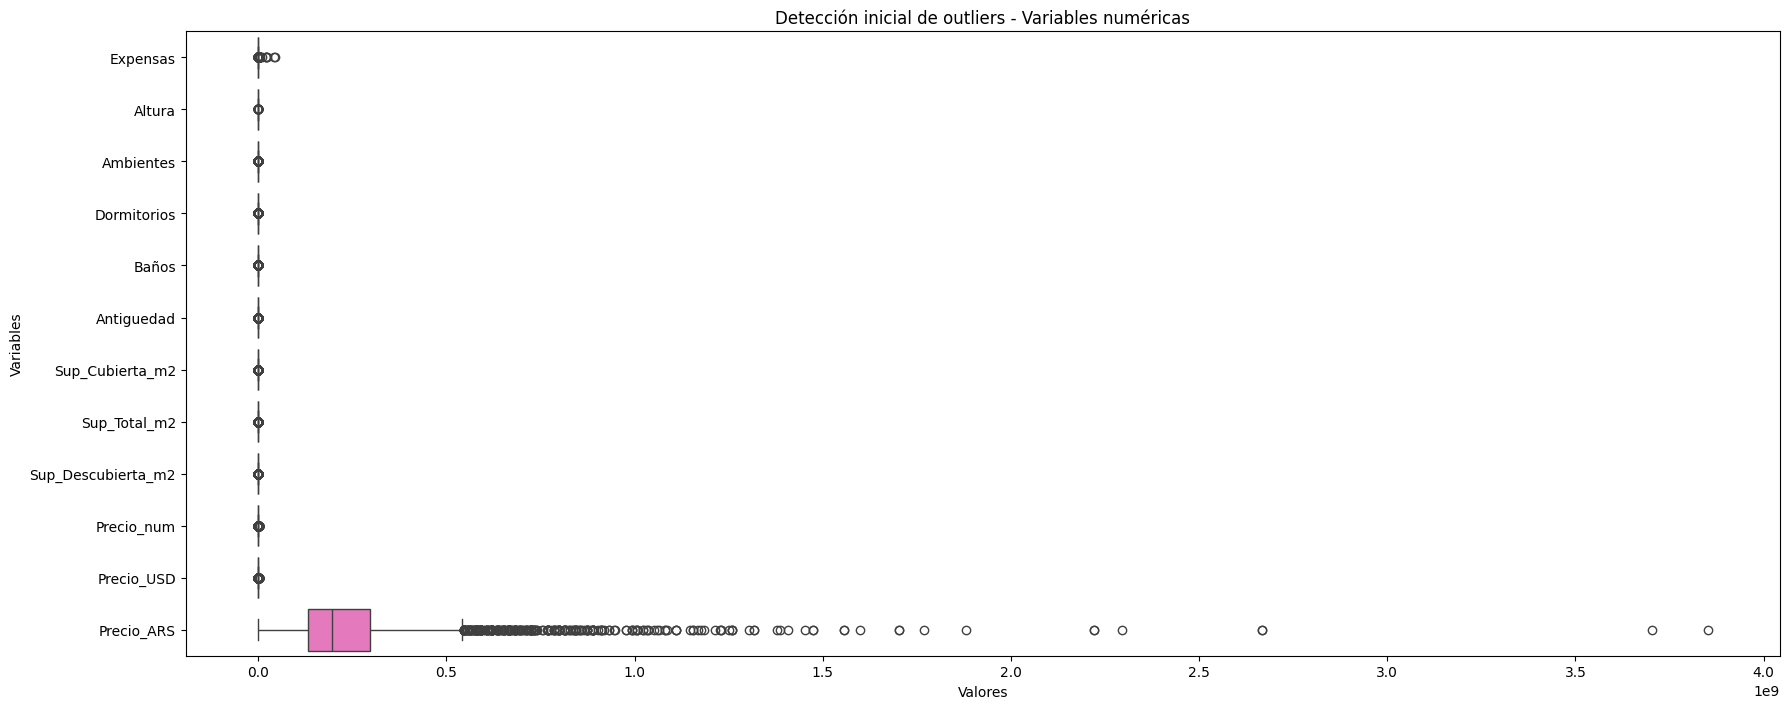

In [312]:
# Seleccionar variables numéricas
variables_numericas = df_ventas_completo.select_dtypes(
    include=['int64', 'float64']
).columns

variables_numericas = [
    col for col in variables_numericas
    if df_ventas_completo[col].nunique() > 2
]

# Tamaño dinámico según cantidad de variables
plt.figure(figsize=(18, len(variables_numericas) * 0.6))

# Boxplot horizontal
sns.boxplot(
    data=df_ventas_completo[variables_numericas],
    orient='h'
)

plt.title('Detección inicial de outliers - Variables numéricas')
plt.xlabel('Valores')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

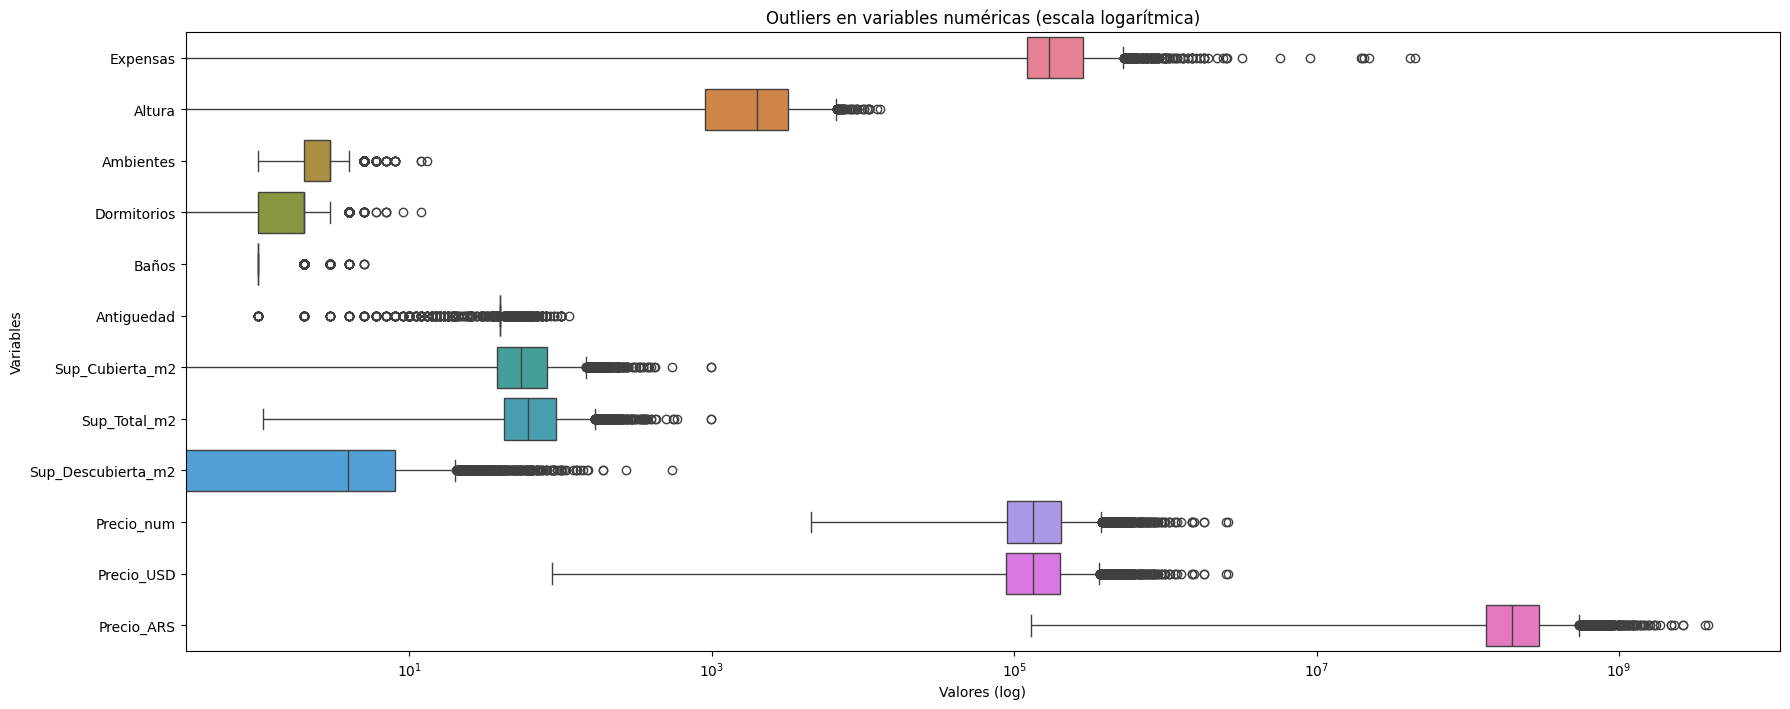

In [313]:
plt.figure(figsize=(18, len(variables_numericas) * 0.6))

sns.boxplot(
    data=df_ventas_completo[variables_numericas],
    orient='h'
)

plt.xscale('log')

plt.title('Outliers en variables numéricas (escala logarítmica)')
plt.xlabel('Valores (log)')
plt.ylabel('Variables')

plt.tight_layout()
plt.show()

In [314]:
num_cols = [
    'Precio_USD',
    'Precio_ARS',
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Sup_Descubierta_m2',
    'Expensas',
    'Antiguedad',
    'Baños',
    'Dormitorios',
    'Ambientes',
    'Altura'
]

for col in num_cols:
    print("\n" + "="*60)
    print(f"VARIABLE: {col}")

    print(
        df_ventas_completo[col].describe(
            percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
        )
    )


VARIABLE: Precio_USD
count    3.893000e+03
mean     1.738661e+05
std      1.530379e+05
min      8.776668e+01
1%       1.700000e+04
5%       5.390000e+04
25%      8.890000e+04
50%      1.330000e+05
75%      2.000000e+05
95%      4.423000e+05
99%      7.500000e+05
max      2.600000e+06
Name: Precio_USD, dtype: float64

VARIABLE: Precio_ARS
count    3.893000e+03
mean     2.575305e+08
std      2.266798e+08
min      1.300000e+05
1%       2.518040e+07
5%       7.983668e+07
25%      1.316787e+08
50%      1.969996e+08
75%      2.962400e+08
95%      6.551348e+08
99%      1.110900e+09
max      3.851120e+09
Name: Precio_ARS, dtype: float64

VARIABLE: Sup_Total_m2
count    3893.000000
mean       77.389639
std        57.696480
min         1.074000
1%         12.500000
5%         27.000000
25%        42.000000
50%        61.060000
75%        93.000000
95%       185.564000
99%       274.501200
max       992.000000
Name: Sup_Total_m2, dtype: float64

VARIABLE: Sup_Cubierta_m2
count    3893.000000
mea

###Expensas:

In [315]:
df_ventas_completo['Expensas'].describe(
    percentiles=[0.90,0.95,0.99]
)

,Expensas
count,3.892000e+03
mean,2.835083e+05
std,1.201997e+06
min,0.000000e+00
50%,1.700000e+05
90%,4.000000e+05
95%,5.636000e+05
99%,1.101855e+06
max,4.457774e+07


In [316]:
df_ventas_completo[
    df_ventas_completo['Expensas'] >
    df_ventas_completo['Expensas'].quantile(0.99)
][['Precio_USD', 'Expensas', 'Sup_Total_m2', 'Tipo_Unidad']]

,Precio_USD,Expensas,Sup_Total_m2,Tipo_Unidad
0,2500000.0,2400000.0,280.00,Departamento
15,599000.0,1160000.0,198.00,Departamento
190,780000.0,1245000.0,313.00,Semipiso
461,579000.0,1198800.0,245.00,Piso
903,449000.0,1500000.0,253.00,Piso
970,730000.0,1790000.0,211.00,Piso
1706,1800000.0,3200000.0,426.00,Piso
1832,1050000.0,1150000.0,164.00,Departamento
1838,1270000.0,1900000.0,180.00,Departamento
1869,1500000.0,1300000.0,293.00,Piso


In [317]:
#Detectar expensas absurdas respecto al precio
df_ventas_completo['ratio_expensas_precio'] = (
    df_ventas_completo['Expensas'] /
    df_ventas_completo['Precio_ARS']
)

In [318]:
df_ventas_completo['ratio_expensas_precio'].describe(
    percentiles=[0.90,0.95,0.99]
)

,ratio_expensas_precio
count,3892.000000
mean,0.003131
std,0.054438
min,0.000000
50%,0.000938
90%,0.001691
95%,0.002071
99%,0.004054
max,2.453988


In [319]:
outliers_expensas = df_ventas_completo[
    df_ventas_completo['ratio_expensas_precio'] > 0.05
]

In [320]:
#Imputar esos outliers con NaN para luego imputar nuevamente
df_ventas_completo.loc[
    df_ventas_completo['ratio_expensas_precio'] > 0.05,
    'Expensas'
] = np.nan

In [321]:
#Imputacion
df_ventas_completo.groupby('Tipo_Unidad')['Expensas'].apply(
    lambda x: x.isnull().mean()*100
)

,Expensas
Tipo_Unidad,
Casa,0.000000
Departamento,0.474355
Duplex,0.000000
Loft,33.333333
Penthouse,0.000000
Ph,0.000000
Piso,0.332226
Semipiso,0.000000


In [322]:
df_ventas_completo['Expensas'] = (
    df_ventas_completo.groupby(
        ['Tipo_Unidad', 'rango_sup']
    )['Expensas']
    .transform(lambda x: x.fillna(x.median()))
)

/tmp/ipykernel_19180/2420716802.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ventas_completo.groupby(


In [323]:
mediana_expensas = df_ventas_completo['Expensas'].median()

df_ventas_completo['Expensas'] = (
    df_ventas_completo['Expensas']
    .fillna(mediana_expensas)
)

###Precio_USD:

In [324]:
#revisar percentiles
df_ventas_completo['Precio_USD'].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

,Precio_USD
count,3.893000e+03
mean,1.738661e+05
std,1.530379e+05
min,8.776668e+01
1%,1.700000e+04
5%,5.390000e+04
25%,8.890000e+04
50%,1.330000e+05
75%,2.000000e+05
95%,4.423000e+05


In [325]:
#revisar los minimos
df_ventas_completo.sort_values(
    'Precio_USD'
)[[
    'Precio_USD',
    'Sup_Total_m2',
    'Tipo_Unidad',
    'Precio'
]].head(20)

,Precio_USD,Sup_Total_m2,Tipo_Unidad,Precio
2803,87.766676,48.00,Departamento,130.000 ARS
2536,110.045909,152.00,Departamento,163.000 ARS
1851,162.030786,74.50,Departamento,ARS 240.000
3695,405.076965,38.00,Departamento,600.000 ARS
2444,405.076965,30.00,Departamento,600.000 ARS
1049,472.589792,130.00,Piso,ARS 700.000
3880,506.346206,31.76,Departamento,750.000 ARS
3834,1012.692412,79.00,Departamento,1.500.000 ARS
3094,4500.000000,13.21,Departamento,4.500 USD
3096,4500.000000,12.43,Departamento,4.500 USD


In [326]:
#Elimina inconsistencias (no puede haber un departamento en venta por 88USD)
df_ventas_completo = df_ventas_completo[
    ~(
        (df_ventas_completo['Moneda'] == 'ARS') &
        (df_ventas_completo['Precio_USD'] < 10000)
    )
]

In [327]:
df_ventas_completo.nlargest(15, 'Precio_USD')[
    ['Tipo_Unidad','Precio_USD','Sup_Total_m2']
]

,Tipo_Unidad,Precio_USD,Sup_Total_m2
3677,Departamento,2600000.0,587.39
0,Departamento,2500000.0,280.00
1706,Piso,1800000.0,426.00
4476,Departamento,1800000.0,357.77
1891,Departamento,1550000.0,362.00
1869,Piso,1500000.0,293.00
4104,Departamento,1500000.0,498.00
1838,Departamento,1270000.0,180.00
3902,Departamento,1195000.0,1.31
525,Piso,1150018.0,163.00


###Sup_Total_m2:

In [328]:
df_ventas_completo['Sup_Total_m2'].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

,Sup_Total_m2
count,3885.000000
mean,77.398869
std,57.722227
min,1.074000
1%,12.500000
5%,27.000000
25%,42.000000
50%,61.060000
75%,93.000000
95%,185.628000


In [329]:
df_ventas_completo.sort_values(
    'Sup_Total_m2'
)[[
    'Sup_Total_m2',
    'Sup_Cubierta_m2',
    'Precio_USD',
    'Tipo_Unidad',
    'Ambientes'
]].head(20)

,Sup_Total_m2,Sup_Cubierta_m2,Precio_USD,Tipo_Unidad,Ambientes
4027,1.074,1.063,329000.0,Departamento,4.0
3902,1.310,1.310,1195000.0,Departamento,5.0
220,3.937,3.667,89000.0,Departamento,2.0
1139,6.000,0.000,249500.0,Departamento,3.0
3472,9.260,9.260,24500.0,Departamento,1.0
2875,10.000,10.000,25000.0,Departamento,1.0
4286,10.000,10.000,21000.0,Departamento,1.0
3608,10.200,10.200,17000.0,Departamento,1.0
4341,10.640,10.640,13000.0,Departamento,1.0
3119,10.650,10.650,18298.0,Departamento,1.0


In [330]:
#eliminacion de valores menores a 9 ya que es muy dificil que eso representa a una propiedad real.
df_ventas_completo = df_ventas_completo[
    df_ventas_completo['Sup_Total_m2'] >= 9
]

###Sup_Cubierta_m2:

In [331]:
#validacion de coherencia logica
df_ventas_completo = df_ventas_completo[
    df_ventas_completo['Sup_Cubierta_m2']
    <=
    df_ventas_completo['Sup_Total_m2']
]

In [332]:
df_ventas_completo.nlargest(20, 'Sup_Cubierta_m2')[
    [
        'Tipo_Unidad',
        'Sup_Cubierta_m2',
        'Sup_Total_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Sup_Cubierta_m2,Sup_Total_m2,Precio_USD
4345,Departamento,992.00,992.00,449999.0
4346,Departamento,992.00,992.00,449000.0
3677,Departamento,549.36,587.39,2600000.0
4104,Departamento,424.00,498.00,1500000.0
1706,Piso,415.00,426.00,1800000.0
3301,Departamento,393.00,393.00,170000.0
3898,Departamento,383.00,421.00,830000.0
3065,Departamento,377.00,556.00,995000.0
3310,Departamento,374.00,374.00,395000.0
3374,Departamento,350.00,367.00,550000.0


Se analizaron los valores extremos de la variable Sup_Cubierta_m2 mediante percentiles y revisión manual de los registros máximos. Si bien existen superficies considerablemente altas, estas resultaron plausibles dentro del mercado inmobiliario y coherentes con la superficie total y el precio de las propiedades. Por lo tanto, no se eliminaron registros únicamente por presentar valores elevados.

###Sup_Descubierta_m2:

In [333]:
df_ventas_completo = df_ventas_completo[
    df_ventas_completo['Sup_Descubierta_m2']
    <=
    df_ventas_completo['Sup_Total_m2']
]

In [334]:
df_ventas_completo.nlargest(20, 'Sup_Descubierta_m2')[
    [
        'Tipo_Unidad',
        'Sup_Descubierta_m2',
        'Sup_Total_m2',
        'Sup_Cubierta_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Sup_Descubierta_m2,Sup_Total_m2,Sup_Cubierta_m2,Precio_USD
2995,Departamento,545.78,558.00,12.22,600000.0
929,Departamento,190.00,358.00,168.00,550000.0
3428,Departamento,189.60,357.60,168.00,550000.0
4206,Departamento,151.35,257.55,106.20,325000.0
2462,Departamento,149.00,243.00,94.00,145000.0
3467,Departamento,140.25,248.33,108.08,670000.0
1447,Departamento,135.00,221.00,86.00,199000.0
1891,Departamento,128.00,362.00,234.00,1550000.0
1267,Departamento,127.00,202.00,75.00,295000.0
4028,Departamento,120.00,200.00,80.00,275000.0


El análisis permitió observar que muchos de estos registros resultan plausibles dentro del contexto inmobiliario, especialmente en propiedades con:

* terrazas amplias,
* patios,
* balcones grandes,
* o espacios semicubiertos.

###Ambientes:

In [335]:
df_ventas_completo.nlargest(20, 'Ambientes')[
    [
        'Tipo_Unidad',
        'Ambientes',
        'Dormitorios',
        'Baños',
        'Sup_Total_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Ambientes,Dormitorios,Baños,Sup_Total_m2,Precio_USD
3255,Departamento,13.0,12.0,1,175.00,163000.0
2995,Departamento,12.0,9.0,1,558.00,600000.0
3677,Departamento,12.0,7.0,1,587.39,2600000.0
1442,Piso,8.0,7.0,2,180.00,189000.0
2481,Departamento,8.0,2.0,1,200.00,160000.0
3065,Departamento,8.0,5.0,1,556.00,995000.0
3476,Departamento,8.0,7.0,1,398.90,775000.0
3898,Departamento,8.0,5.0,1,421.00,830000.0
4104,Departamento,8.0,5.0,1,498.00,1500000.0
1070,Semipiso,7.0,6.0,1,115.00,120000.0


En estos registros, la relación entre cantidad de ambientes, dormitorios y superficie total resulta poco habitual, lo que podría indicar:

- errores de carga,
- criterios distintos de contabilización de ambientes,
- o propiedades no residenciales mal clasificadas.

No obstante, debido a la falta de información adicional que permita confirmar inconsistencias, se decidió no eliminar automáticamente estos registros en esta etapa del análisis.

Por lo tanto, la variable Ambientes fue conservada sin recortes automáticos, priorizando mantener propiedades extremas pero plausibles dentro del mercado inmobiliario.

###Dormitorios:

In [336]:
df_ventas_completo.nlargest(20, 'Dormitorios')[
    [
        'Tipo_Unidad',
        'Dormitorios',
        'Ambientes',
        'Baños',
        'Sup_Total_m2',
        'Precio_USD'
    ]
]

,Tipo_Unidad,Dormitorios,Ambientes,Baños,Sup_Total_m2,Precio_USD
3255,Departamento,12.0,13.0,1,175.00,163000.0
2995,Departamento,9.0,12.0,1,558.00,600000.0
1442,Piso,7.0,8.0,2,180.00,189000.0
3476,Departamento,7.0,8.0,1,398.90,775000.0
3677,Departamento,7.0,12.0,1,587.39,2600000.0
1070,Semipiso,6.0,7.0,1,115.00,120000.0
1607,Semipiso,6.0,7.0,1,250.00,139000.0
781,Semipiso,5.0,6.0,2,298.00,385000.0
1203,Ph,5.0,6.0,3,128.00,180000.0
1263,Departamento,5.0,6.0,1,186.00,355000.0


In [337]:
#Eliminacion con filtro para no eliminar propiedades de lujo
df_ventas_completo = df_ventas_completo[
    ~(
        (df_ventas_completo['Dormitorios'] >= 6) &
        (df_ventas_completo['Sup_Total_m2'] < 150)
    )
]

#Exportar csv


In [338]:
df_ventas_completo.to_csv('dataset_ventas_limpio.csv', index=False)